# **PHẦN 6: CLUSTERING**
## **1. Định nghĩa vấn đề**
+ **Mô tả**:
   - Thực hiện clustering để phát hiện ra mối quan hệ trong tập dữ liệu

## **2. Chuẩn bị vấn đề**

### 2.1. Import các thư viện

In [ ]:
import pandas as pd
import numpy as np

### 2.2. Tải dataset

In [ ]:
x_train = pd.read_parquet("../data_processed/x_train.parquet")
x_val = pd.read_parquet("../data_processed/x_val.parquet")

y_train = pd.read_parquet("../data_processed/y_train.parquet")
y_val = pd.read_parquet("../data_processed/y_val.parquet")

In [ ]:
if isinstance(y_train, pd.DataFrame):
    y_train = y_train.iloc[:, 0]

if isinstance(y_val, pd.DataFrame):
    y_val = y_val.iloc[:, 0]

print(x_train.shape)
print(x_val.shape)

(284500, 119)
(35563, 119)


## **3. Thực hiện vấn đề**

### 3.1. Chọn các features cần cluster

In [ ]:
traffic_features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Length of Fwd Packets",
    "Fwd Packet Length Max",
    "Bwd Packet Length Max",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Fwd Header Length",
    "Bwd Packets/s",
    "Min Packet Length",
    "Down/Up Ratio",
    "Init_Win_bytes_backward"
]

temporal_features = [
    "Flow IAT Mean",
    "Flow IAT Std",
    "Bwd IAT Total",
    "Bwd IAT Mean",
    "Active Mean",
    "Active Std",
    "Idle Mean",
    "Idle Std",
    "Hour_sin",
    "Hour_cos",
    "Day_sin",
    "Day_cos"
]

protocol_features = [
    "Protocol_0.0",
    "Protocol_6.0",
    "Protocol_17.0",

    "Destination Port_Flag_HTTP",
    "Destination Port_Flag_HTTPS",
    "Destination Port_Flag_DNS",
    "Destination Port_Flag_SSDP",
    "Destination Port_Flag_Dynamic"
]

port_group_features = [
    "Source Port_Grp_System",
    "Source Port_Grp_Registered",
    "Source Port_Grp_Dynamic",

    "Destination Port_Grp_System",
    "Destination Port_Grp_Registered",
    "Destination Port_Grp_Dynamic"
]



In [ ]:
selected_features = (
    traffic_features
    + temporal_features
    + protocol_features
    + port_group_features
)


selected_features = [
    col for col in selected_features
    if col in x_train.columns
]

print(f"Total selected features: {len(selected_features)}")


X_train = x_train[selected_features].copy()
X_val = x_val[selected_features].copy()

print(X_train.shape)


Total selected features: 29
(284500, 29)


### 3.2. Loại bỏ các low variance

In [ ]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.001)

X_train_var = selector.fit_transform(X_train)
X_val_var = selector.transform(X_val)

selected_after_var = np.array(selected_features)[selector.get_support()]

print("After variance threshold:")
print(X_train_var.shape)

After variance threshold:
(284500, 29)


### 3.3. PCA

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=0.95,
    random_state=42
)

X_train_pca = pca.fit_transform(X_train_var)
X_val_pca = pca.transform(X_val_var)

print("PCA shape:")
print(X_train_pca.shape)

print(
    "Explained variance:",
    np.sum(pca.explained_variance_ratio_)
)


PCA shape:
(284500, 6)
Explained variance: 0.961188002611548


### 3.4. UMAP

In [ ]:
import umap.umap_ as umap

umap_model = umap.UMAP(
    n_neighbors=50,
    min_dist=0.0,
    n_components=20,
    metric="cosine",
    random_state=42
)

X_train_umap = umap_model.fit_transform(X_train_pca)
X_val_umap = umap_model.transform(X_val_pca)

print("UMAP shape:")
print(X_train_umap.shape)

d:\Installs\Anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP shape:
(284500, 20)


### 3.5. HDBScan

In [ ]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=300,
    min_samples=30,
    metric="euclidean",
    cluster_selection_method="leaf"
)

train_clusters = clusterer.fit_predict(X_train_umap)

print("\nCluster distribution:")
print(pd.Series(train_clusters).value_counts())


Cluster distribution:
-1      94411
 188     2066
 277     1865
 110     1814
 70      1747
        ...  
 48       302
 41       301
 297      301
 222      301
 185      301
Name: count, Length: 315, dtype: int64


### 3.6. Phân tích Cluster Purity

In [ ]:
cluster_analysis = pd.crosstab(
    train_clusters,
    y_train,
    normalize="index"
)

print("\nCluster purity:")
print(cluster_analysis)


Cluster purity:
Label         0         1         2         3
row_0                                        
-1     0.400981  0.330989  0.200591  0.067439
 0     0.520588  0.297059  0.082353  0.100000
 1     0.720841  0.166348  0.082218  0.030593
 2     0.512718  0.327979  0.105756  0.053548
 3     0.549199  0.283753  0.132723  0.034325
...         ...       ...       ...       ...
 309   0.383133  0.272289  0.250602  0.093976
 310   0.262712  0.299435  0.367232  0.070621
 311   0.389509  0.313616  0.225446  0.071429
 312   0.353403  0.259162  0.306283  0.081152
 313   0.314465  0.301887  0.305031  0.078616

[315 rows x 4 columns]


### 3.7. Đánh giá Silhouette Score

In [ ]:
from sklearn.metrics import silhouette_score

mask = train_clusters != -1

if len(np.unique(train_clusters[mask])) > 1:
    score = silhouette_score(
        X_train_umap[mask],
        train_clusters[mask]
    )

    print("\nSilhouette Score:", score)



Silhouette Score: 0.5630795359611511


### 3.8. Biểu diễn UMAP

In [ ]:
umap_vis = umap.UMAP(
    n_neighbors=50,
    min_dist=0.0,
    n_components=2,
    metric="cosine",
    random_state=42
)

X_vis = umap_vis.fit_transform(X_train_pca)

d:\Installs\Anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### 3.9. Plot clusters

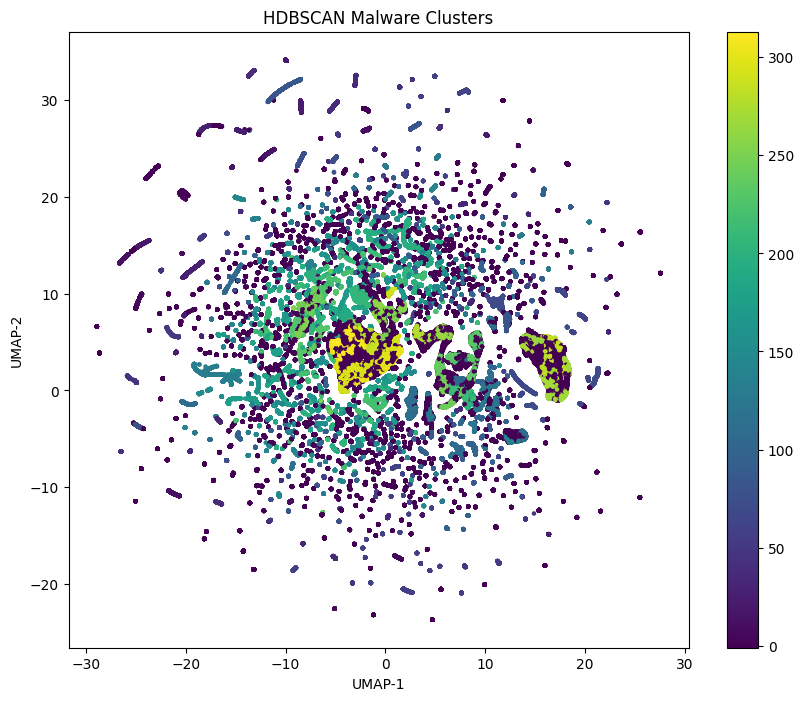

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=train_clusters,
    s=5
)

plt.title("HDBSCAN Malware Clusters")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.colorbar(scatter)

plt.show()

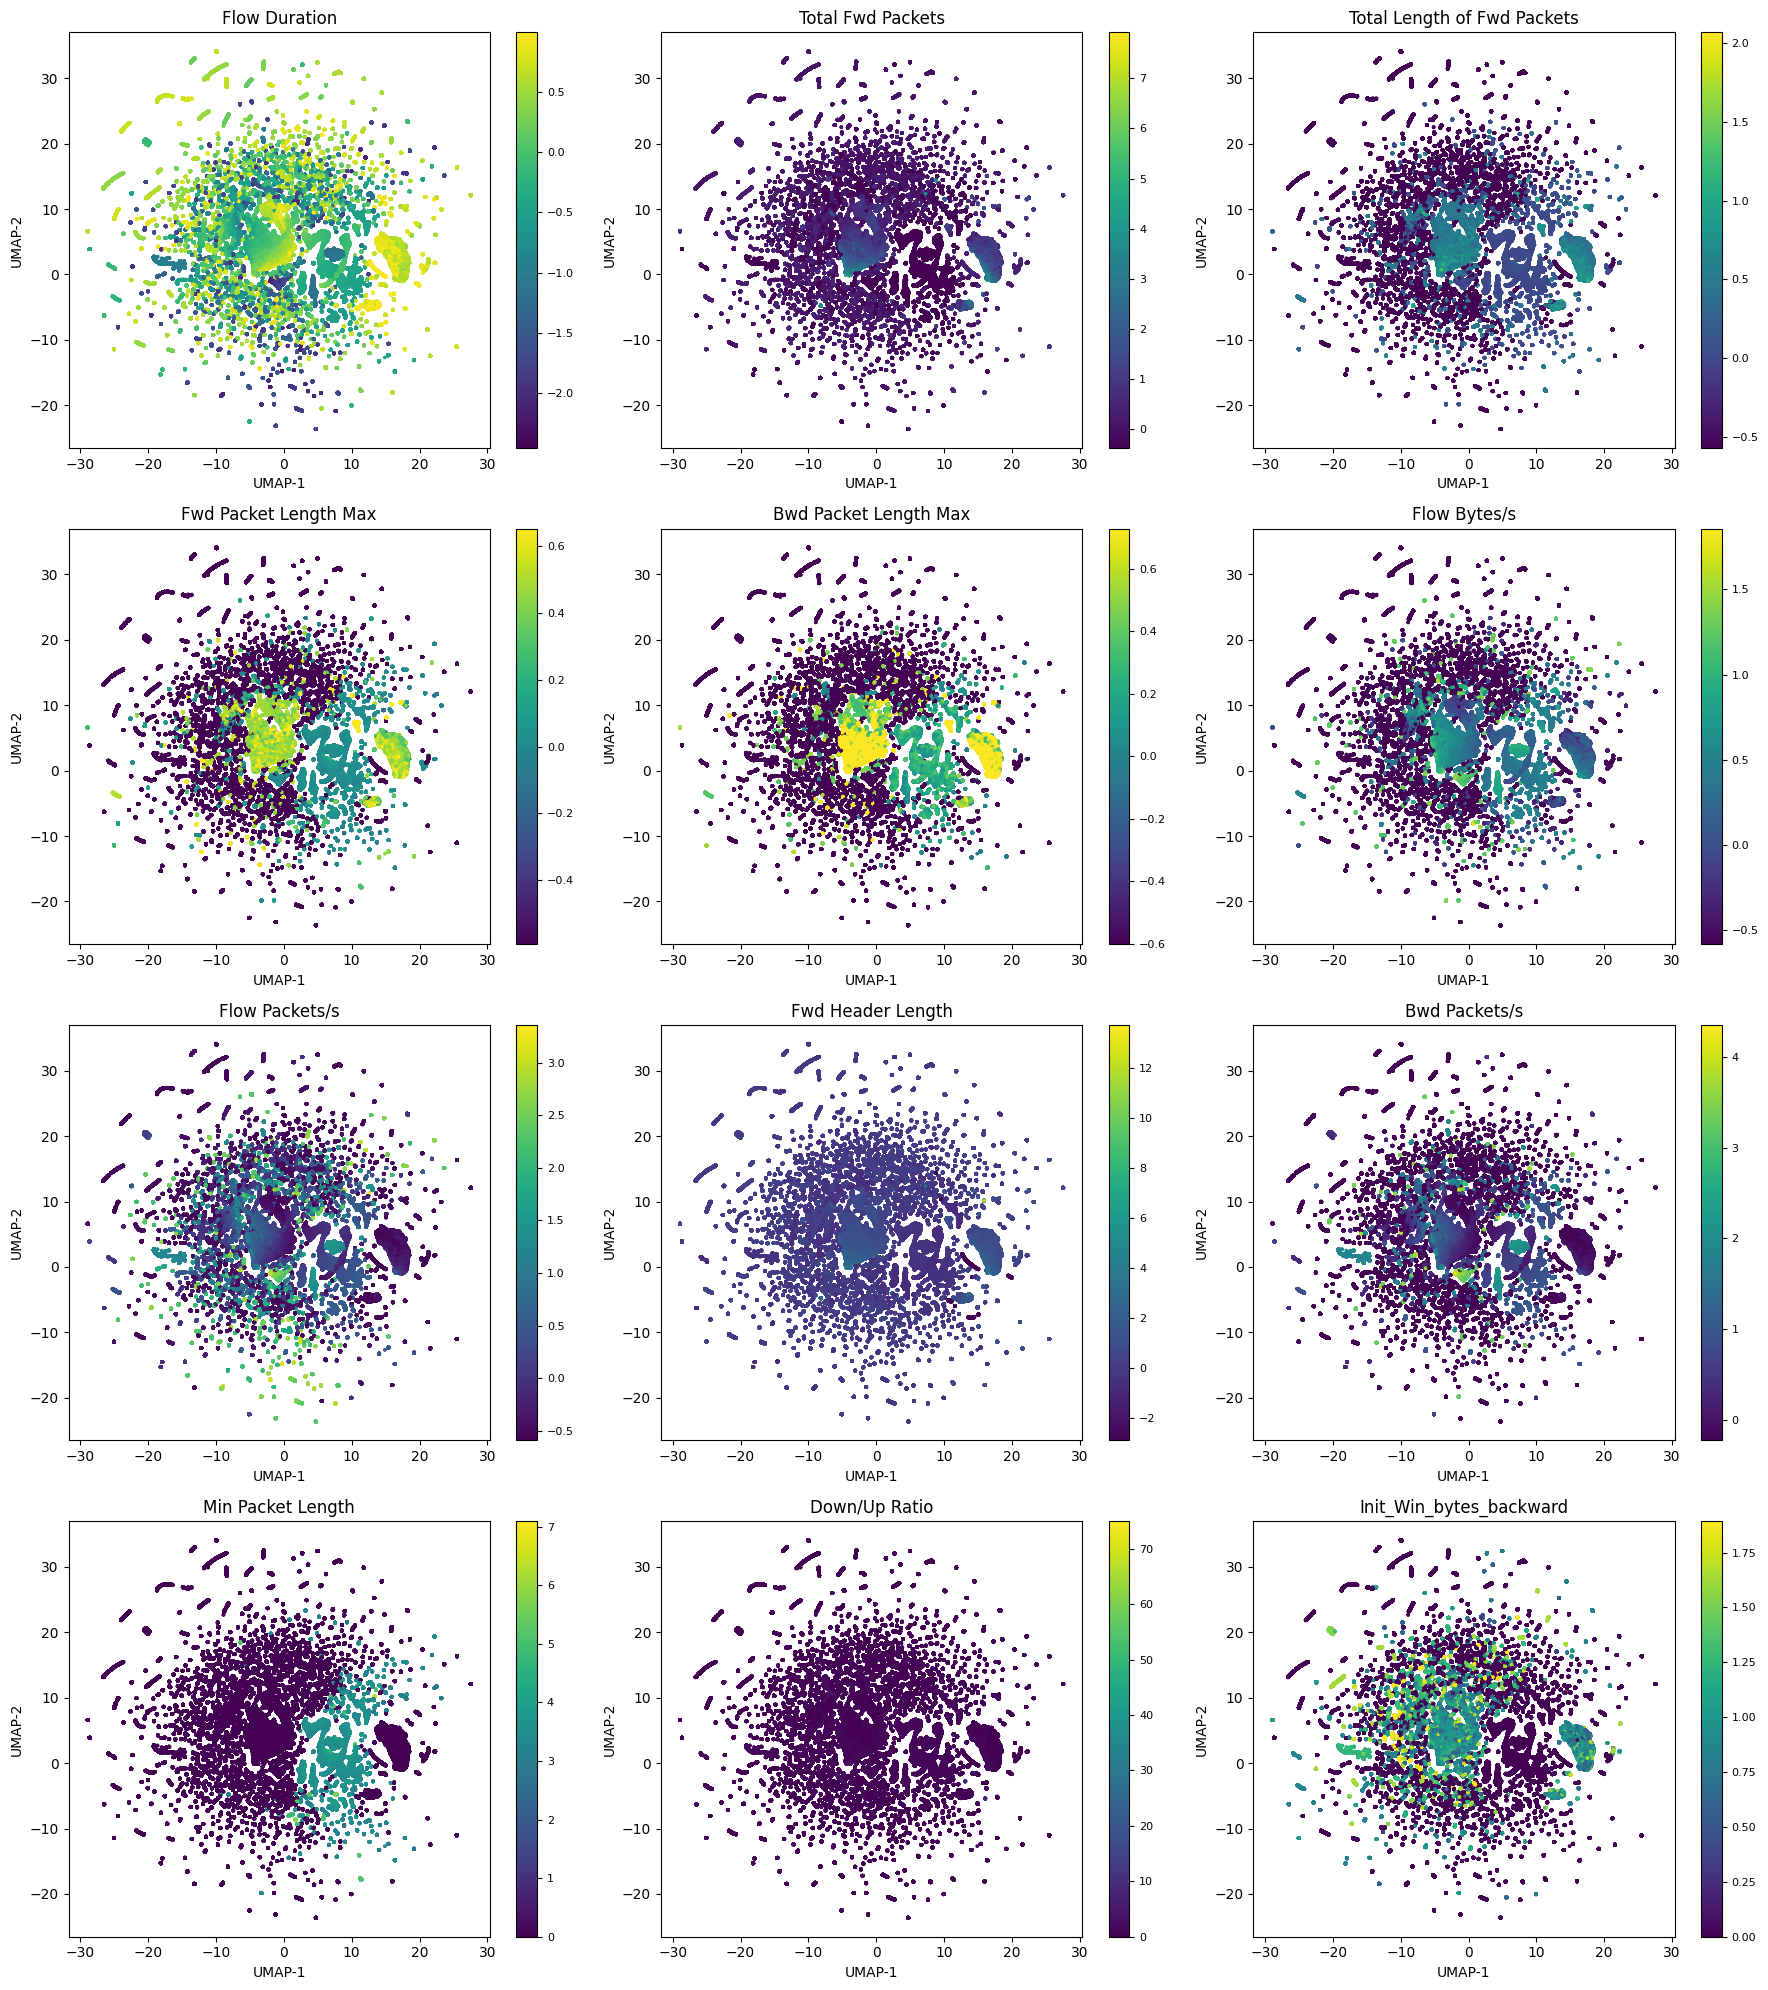

In [ ]:

traffic_features = [
    col for col in traffic_features
    if col in x_train.columns
]

n_features = len(traffic_features)

n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for i, feature in enumerate(traffic_features):

    scatter = axes[i].scatter(
        X_vis[:, 0],
        X_vis[:, 1],
        c=x_train[feature],
        s=3,
        cmap="viridis"
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel("UMAP-1")
    axes[i].set_ylabel("UMAP-2")

    cbar = plt.colorbar(
        scatter,
        ax=axes[i]
    )

    cbar.ax.tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()

plt.show()

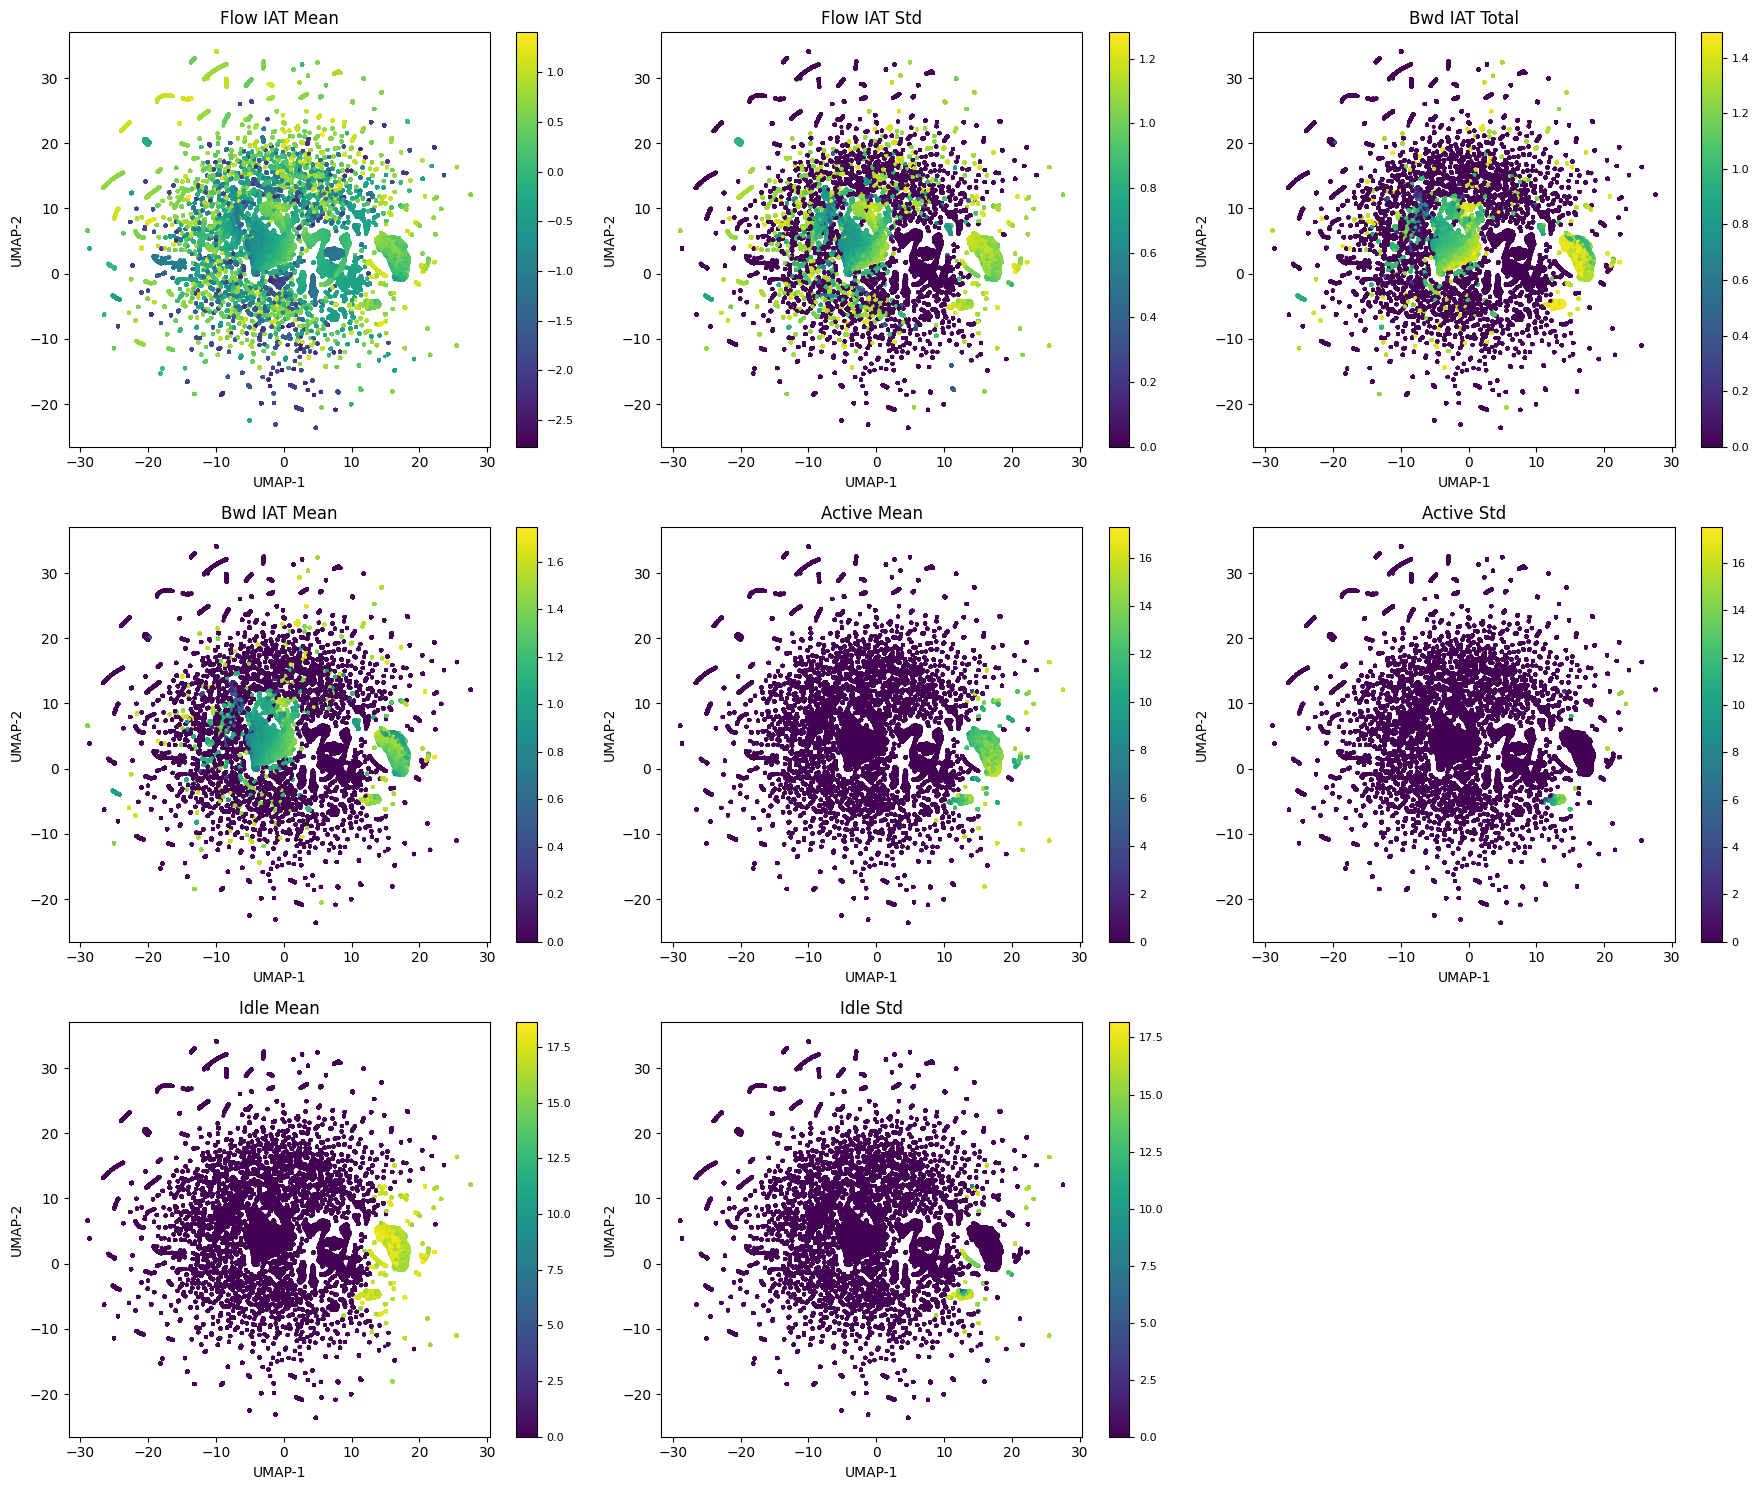

In [ ]:

temporal_features = [
    col for col in temporal_features
    if col in x_train.columns
]

n_features = len(temporal_features)

n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for i, feature in enumerate(temporal_features):

    scatter = axes[i].scatter(
        X_vis[:, 0],
        X_vis[:, 1],
        c=x_train[feature],
        s=3,
        cmap="viridis"
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel("UMAP-1")
    axes[i].set_ylabel("UMAP-2")

    cbar = plt.colorbar(
        scatter,
        ax=axes[i]
    )

    cbar.ax.tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()

plt.show()

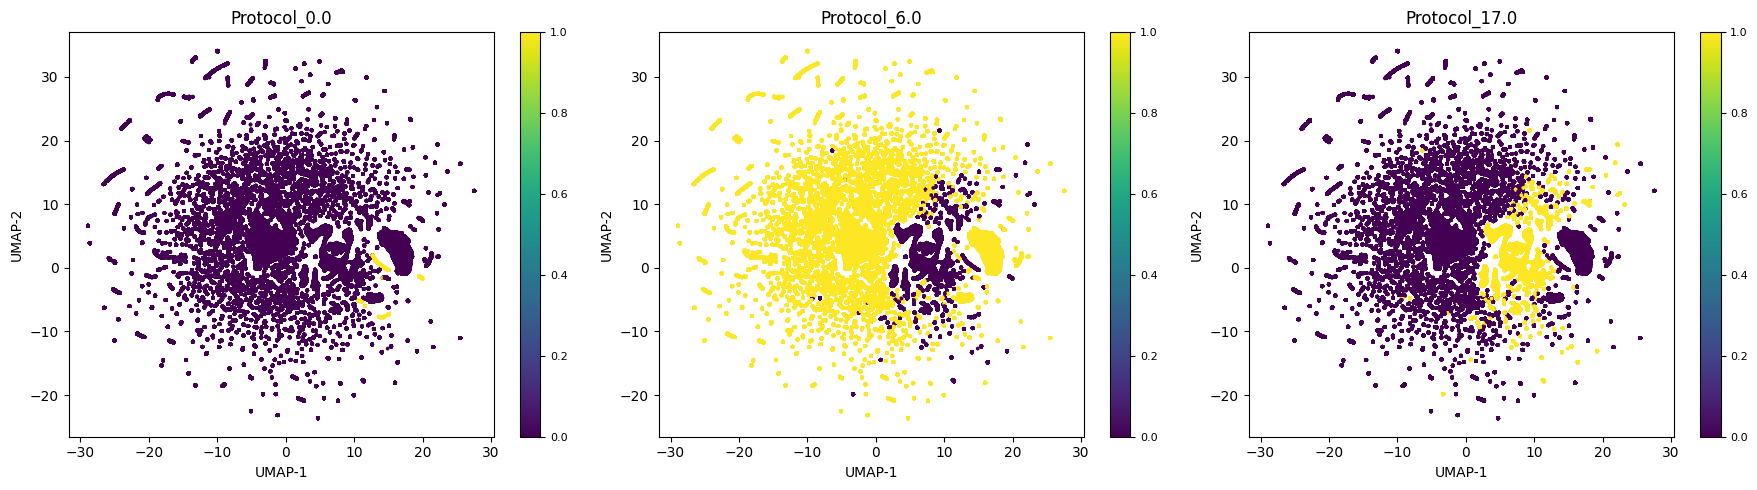

In [ ]:

protocol_features = [
    col for col in protocol_features
    if col in x_train.columns
]

n_features = len(protocol_features)

n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for i, feature in enumerate(protocol_features):

    scatter = axes[i].scatter(
        X_vis[:, 0],
        X_vis[:, 1],
        c=x_train[feature],
        s=3,
        cmap="viridis"
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel("UMAP-1")
    axes[i].set_ylabel("UMAP-2")

    cbar = plt.colorbar(
        scatter,
        ax=axes[i]
    )

    cbar.ax.tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()

plt.show()

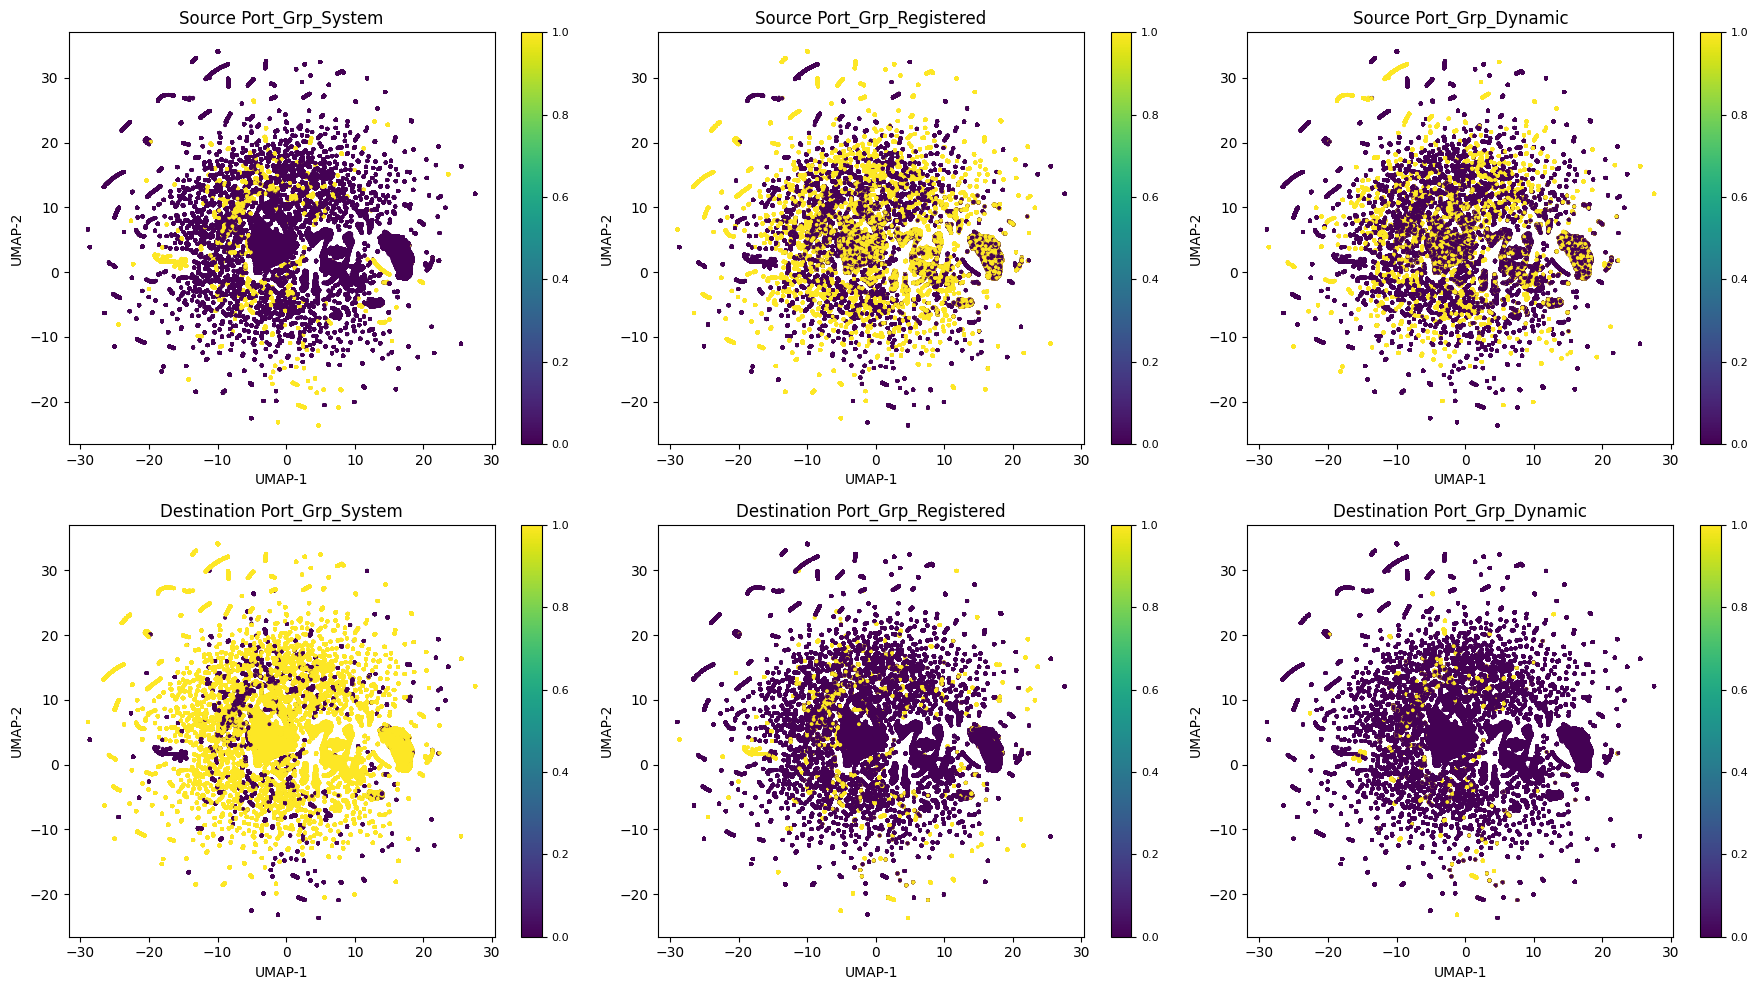

In [ ]:

port_group_features = [
    col for col in port_group_features
    if col in x_train.columns
]

n_features = len(port_group_features)

n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for i, feature in enumerate(port_group_features):

    scatter = axes[i].scatter(
        X_vis[:, 0],
        X_vis[:, 1],
        c=x_train[feature],
        s=3,
        cmap="viridis"
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel("UMAP-1")
    axes[i].set_ylabel("UMAP-2")

    cbar = plt.colorbar(
        scatter,
        ax=axes[i]
    )

    cbar.ax.tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()

plt.show()

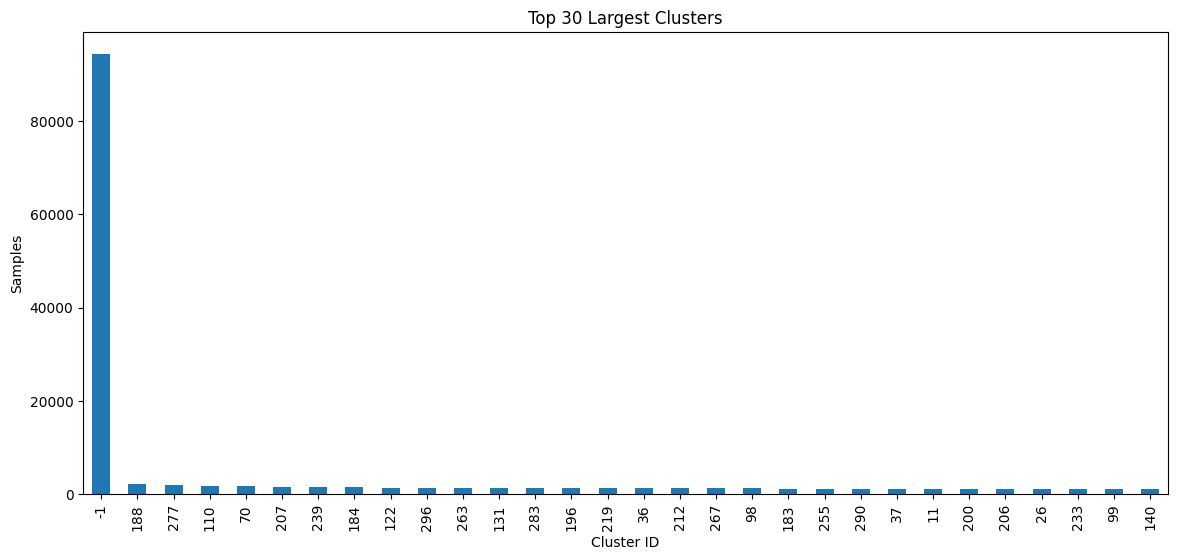

In [ ]:
cluster_counts = (
    pd.Series(train_clusters)
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 6))

cluster_counts.head(30).plot(
    kind="bar"
)

plt.title("Top 30 Largest Clusters")
plt.xlabel("Cluster ID")
plt.ylabel("Samples")

plt.show()

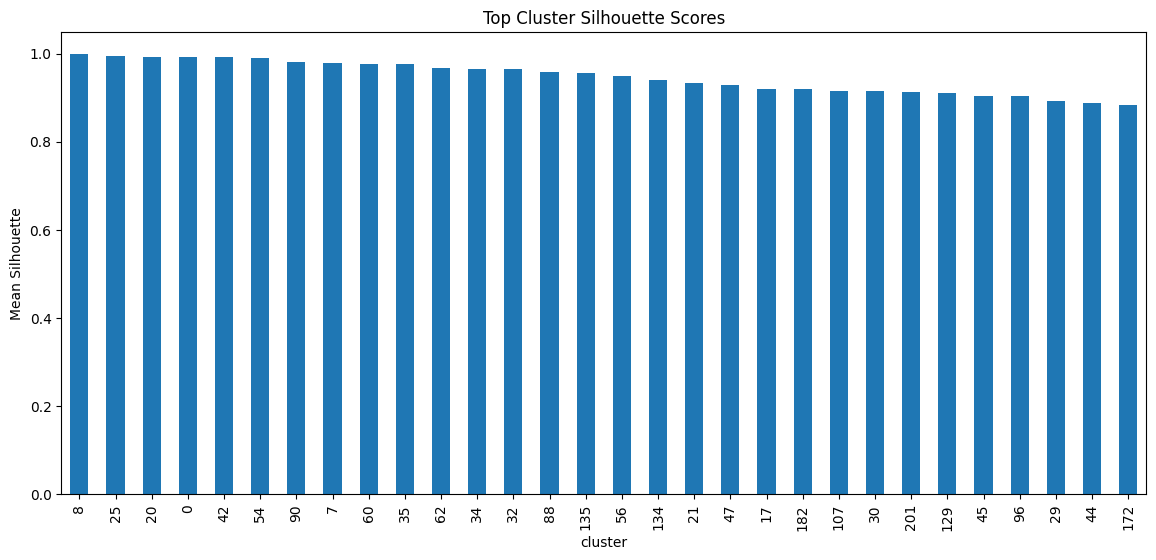

In [ ]:
from sklearn.metrics import silhouette_samples

mask = train_clusters != -1

sample_scores = silhouette_samples(
    X_train_umap[mask],
    train_clusters[mask]
)

cluster_score_df = pd.DataFrame({
    "cluster": train_clusters[mask],
    "score": sample_scores
})

cluster_mean_scores = (
    cluster_score_df
    .groupby("cluster")["score"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 6))

cluster_mean_scores.head(30).plot(
    kind="bar"
)

plt.title("Top Cluster Silhouette Scores")
plt.ylabel("Mean Silhouette")

plt.show()

# **Kết thúc**